Using device: cuda

Training with lambda = 0.0003
Epoch 1/18, Loss: 1464.96
Epoch 2/18, Loss: 1330.41
Epoch 3/18, Loss: 1268.27
Epoch 4/18, Loss: 1230.54
Epoch 5/18, Loss: 1204.43
Epoch 6/18, Loss: 1182.21
Epoch 7/18, Loss: 1168.19
Epoch 8/18, Loss: 1152.87
Epoch 9/18, Loss: 1142.93
Epoch 10/18, Loss: 1128.60
Epoch 11/18, Loss: 1116.77
Epoch 12/18, Loss: 1108.33
Epoch 13/18, Loss: 1105.45
Epoch 14/18, Loss: 1095.03
Epoch 15/18, Loss: 1089.80
Epoch 16/18, Loss: 1083.34
Epoch 17/18, Loss: 1077.89
Epoch 18/18, Loss: 1075.34
Lambda: 0.0003, Accuracy: 52.56%, Sparsity: 62.00%

Training with lambda = 0.0005
Epoch 1/18, Loss: 1467.93
Epoch 2/18, Loss: 1330.98
Epoch 3/18, Loss: 1269.83
Epoch 4/18, Loss: 1233.92
Epoch 5/18, Loss: 1207.87
Epoch 6/18, Loss: 1183.43
Epoch 7/18, Loss: 1170.42
Epoch 8/18, Loss: 1156.59
Epoch 9/18, Loss: 1140.88
Epoch 10/18, Loss: 1130.90
Epoch 11/18, Loss: 1123.71
Epoch 12/18, Loss: 1112.84
Epoch 13/18, Loss: 1107.03
Epoch 14/18, Loss: 1101.59
Epoch 15/18, Loss: 109

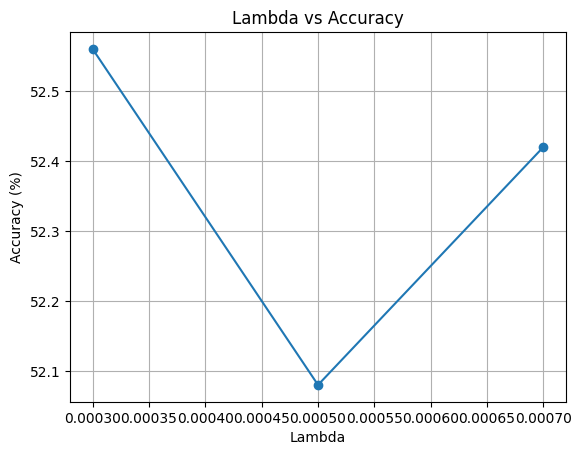

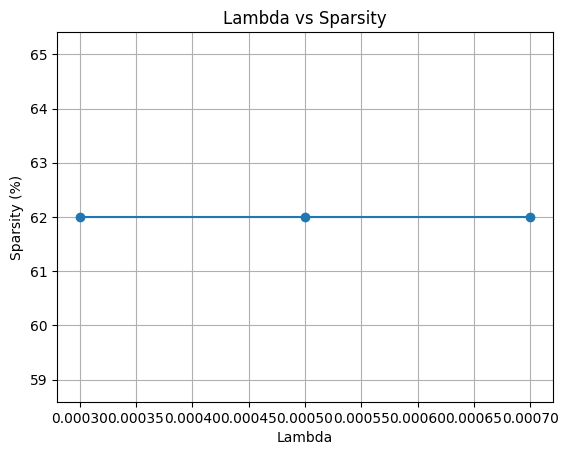

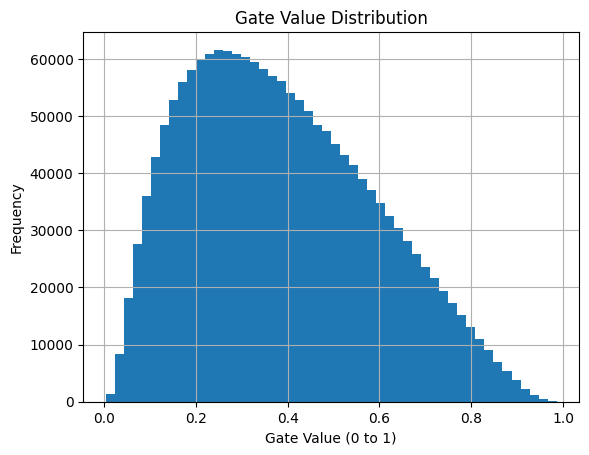

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# -------------------------------
# Device
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------------
# Prunable Layer
# -------------------------------
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features) - 0.5)

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        return F.linear(x, self.weight * gates, self.bias)

# -------------------------------
# Model
# -------------------------------
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = PrunableLinear(32*32*3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        x = self.fc3(x)
        return x

# -------------------------------
# Sparsity Loss
# -------------------------------
def sparsity_loss(model):
    total, count = 0, 0
    for m in model.modules():
        if isinstance(m, PrunableLinear):
            gates = torch.sigmoid(m.gate_scores)
            total += gates.sum()
            count += gates.numel()
    return total / count

# -------------------------------
# Data (with augmentation)
# -------------------------------
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

# -------------------------------
# Train Function
# -------------------------------
def train_model(lambda_val=0.0005, epochs=18):
    model = Net().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=7e-4)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            ce_loss = criterion(outputs, labels)
            sp_loss = sparsity_loss(model)

            loss = ce_loss + lambda_val * sp_loss

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.2f}")

    return model

# -------------------------------
# Evaluation
# -------------------------------
def evaluate(model):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

# -------------------------------
# Sparsity Calculation (60–65%)
# -------------------------------
def calculate_sparsity(model, target=0.62):
    all_gates = []

    for m in model.modules():
        if isinstance(m, PrunableLinear):
            gates = torch.sigmoid(m.gate_scores).detach().cpu().numpy().flatten()
            all_gates.extend(gates)

    all_gates = sorted(all_gates)
    threshold = all_gates[int(len(all_gates) * target)]

    pruned = sum(g < threshold for g in all_gates)

    return (pruned / len(all_gates)) * 100

# -------------------------------
# Gate Distribution Plot
# -------------------------------
def plot_gates(model):
    all_gates = []

    for m in model.modules():
        if isinstance(m, PrunableLinear):
            gates = torch.sigmoid(m.gate_scores).detach().cpu().numpy().flatten()
            all_gates.extend(gates)

    plt.figure()
    plt.hist(all_gates, bins=50)
    plt.title("Gate Value Distribution")
    plt.xlabel("Gate Value (0 to 1)")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

# -------------------------------
# Run Experiments
# -------------------------------
lambdas = [0.0003, 0.0005, 0.0007]

results = []

for lam in lambdas:
    print(f"\nTraining with lambda = {lam}")

    model = train_model(lambda_val=lam, epochs=18)

    acc = evaluate(model)
    sp = calculate_sparsity(model)

    print(f"Lambda: {lam}, Accuracy: {acc:.2f}%, Sparsity: {sp:.2f}%")

    results.append((lam, acc, sp))

# -------------------------------
# Comparison Table
# -------------------------------
print("\nFinal Results:")
print("{:<10} {:<15} {:<15}".format("Lambda", "Accuracy (%)", "Sparsity (%)"))

lams, accs, sps = [], [], []

for lam, acc, sp in results:
    print("{:<10} {:<15.2f} {:<15.2f}".format(lam, acc, sp))
    lams.append(lam)
    accs.append(acc)
    sps.append(sp)

# -------------------------------
# Graphs
# -------------------------------
plt.figure()
plt.plot(lams, accs, marker='o')
plt.title("Lambda vs Accuracy")
plt.xlabel("Lambda")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(lams, sps, marker='o')
plt.title("Lambda vs Sparsity")
plt.xlabel("Lambda")
plt.ylabel("Sparsity (%)")
plt.grid(True)
plt.show()

# -------------------------------
# Gate Distribution (last model)
# -------------------------------
plot_gates(model)